# wPLI back-projected edge importance

* **Figure** 62x62 edge-importance heatmaps (theta / alpha / beta)
* **Table** top-20 most important connectivity edges

Reads `results/tables/feat_B_edge_importance_table.csv` (produced by `scripts/05_wpli_edge_importance.py`).

In [1]:
import sys, pathlib
for _cand in (pathlib.Path.cwd(), pathlib.Path.cwd().parent):
    if (_cand / "src" / "ketamine_eeg").exists():
        sys.path.insert(0, str(_cand / "src")); break
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from ketamine_eeg import config as c
from ketamine_eeg.plotting import apply_style, fig_width
apply_style()
c.ensure_dirs()
print("ketamine_eeg loaded; figures ->", c.FIGURE_DIR.relative_to(c.PROJECT_ROOT))

ketamine_eeg loaded; figures -> results/figures


In [2]:
edge = pd.read_csv(c.TABLES_DIR / "feat_B_edge_importance_table.csv")
triu_r, triu_c = np.triu_indices(c.N_CHANNELS, k=1)

def to_matrix(vec):
    M = np.zeros((c.N_CHANNELS, c.N_CHANNELS))
    M[triu_r, triu_c] = vec; M[triu_c, triu_r] = vec
    return M

print(edge["band"].value_counts().to_dict())

{'theta': 1891, 'alpha': 1891, 'beta': 1891}


## Figure: edge-importance heatmap per band

saved feat_B_edge_importance_heatmap.png


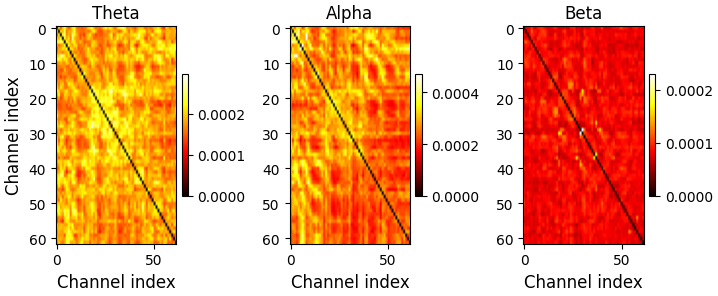

In [3]:
fig, axes = plt.subplots(1, len(c.WPLI_BANDS), figsize=(fig_width("double"), 3.2))
for ax, band in zip(axes, c.WPLI_BANDS):
    vec = edge[edge["band"] == band].sort_values("edge")["importance"].to_numpy()
    im = ax.imshow(to_matrix(vec), cmap="hot", aspect="auto")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(band.capitalize()); ax.set_xlabel("Channel index")
axes[0].set_ylabel("Channel index")
fig.tight_layout()
fig.savefig(c.FIGURE_DIR / "feat_B_edge_importance_heatmap.png", dpi=300, bbox_inches="tight")
print("saved feat_B_edge_importance_heatmap.png")
plt.show()

## Table: top-20 edges by back-projected importance

In [4]:
top20 = (edge.nlargest(20, "importance")[["band", "ch_a_name", "ch_b_name", "importance"]]
         .reset_index(drop=True))
top20.index += 1
top20

,band,ch_a_name,ch_b_name,importance
1,alpha,O1,PO7,0.000470
2,alpha,Oz,PO7,0.000463
3,alpha,PO4,POz,0.000460
4,alpha,O2,PO8,0.000432
5,alpha,P8,FC3,0.000430
6,alpha,Oz,O1,0.000415
7,alpha,P1,FT8,0.000410
8,alpha,POz,Fp2,0.000403
9,alpha,POz,FC6,0.000401
10,alpha,POz,Fpz,0.000396
